# APL case study: single-cell transcriptome analyses

This notebook explores and interprets the intermediate results generated by scBOLT for the PLZF-RARα APL case study. Rather than executing the framework itself, it documents the biological evidence used to formulate the Boolean constraints for formal synthesis.

Each section introduces the corresponding biological question and reproduces the exploratory analyses presented throughout the manuscript.

### Table of contents

1. [Data overview](#data)
2. [Trajectory inference](#potency)
3. [Macrostate characterisation](#macrostates)
4. [Macrostate binarisation](#binarisation)

### Figure index <a class="anchor" id="figure-index"></a>

The notebook exports the following figures. Links jump to the section where each figure is generated.

| Notebook section                                                   | Generated file         |
| ------------------------------------------------------------------ | ---------------------- |
| [Integrated UMAP by condition](#fig-umap-condition)                | `umap_conditions.pdf`  |
| [Integrated UMAP by annotation](#fig-umap-label)                   | `umap_labels.pdf`      |
| [Trajectory inference: CytoTRACE potency](#fig-potency)            | `potency_scores.pdf`   |
| [Macrostate characterisation: KNNSC macrostates](#fig-macrostates) | `umap_macrostates.pdf` |
| [Biological consistency: extended GO panel](#fig-markers-extended) | `markers_extended.pdf` |
| [Biological consistency: paper-focused panel](#fig-markers-paper)  | `markers.pdf`          |


### Notebook setup

In [1]:
%matplotlib inline

# Standard library

import gzip
import shutil
import tempfile
import urllib.request
from collections import deque
from pathlib import Path

import anndata as ad
import bonesistools as bt
import matplotlib.pyplot as plt
import numpy as np

# Third-party packages
import pandas as pd
from goatools.obo_parser import GODag
from IPython.display import display
from matplotlib.patches import Ellipse

# Global display and plotting settings

pd.set_option("future.no_silent_downcasting", True)
bt.omics.pl.set_default_params()

plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

# Case-study directories


def find_project_root(start=None, markers=(".git", "apl")):
    """Locate the case-study root directory from any notebook location."""

    start = Path.cwd() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        f"Could not find project root from {start} using markers {markers}"
    )


PROJECT_DIR = find_project_root()
APL_DIR = PROJECT_DIR / "apl"

RESULTS_DIR = APL_DIR / "results"
FIGURE_DIR = APL_DIR / "figures"
GO_RELEASE = "2026-03-25"
GO_CACHE_DIR = Path(tempfile.gettempdir()) / "scbolt-case-studies" / "go"
GO_BASIC_URL = f"https://release.geneontology.org/{GO_RELEASE}/ontology/go-basic.obo"
GENE2GO_URL = "https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz"

FIGURE_DIR.mkdir(exist_ok=True)

# Biological settings

palette = bt.omics.pl.get_palette("classic")
conditions = ["ctrl", "treated"]
labels_order = ["Prom1", "Prom2", "Rep", "Cycl", "Neu", "Alt"]
label_colors = dict(zip(labels_order, palette.colors))

### Helper functions

In [2]:
# Data and display helpers


def load_h5ad(file, obs_order=None, obs_colors=None):
    """Load an AnnData object with standardised categorical metadata."""

    adata = ad.read_h5ad(file)

    if obs_order is not None:
        for obs, order in obs_order.items():
            categories = list(adata.obs[obs].cat.categories)

            ordered_categories = [x for x in order if x in categories]
            ordered_categories += [x for x in categories if x not in order]

            adata.obs[obs] = adata.obs[obs].cat.reorder_categories(
                ordered_categories,
                ordered=True,
            )

    if obs_colors is not None:
        for obs, colors in obs_colors.items():
            adata.uns[f"{obs}_colors"] = colors

    return adata


def display_counts(counts, index_name="item", count_name="n"):
    """Display a compact count summary."""

    summary = pd.DataFrame(
        [(name, count) for name, count in counts.items()],
        columns=[index_name, count_name],
    )
    display(summary.style.hide(axis="index"))


# Plotting helpers


def add_ellipse(position, length, width, angle=32):
    """Plot an ellipse on the current ax."""

    ax = plt.gca()
    ax.add_patch(
        Ellipse(
            position,
            length,
            width,
            angle=angle,
            facecolor="lightgray",
            edgecolor="none",
            alpha=0.3,
            zorder=0,
            clip_on=False,
        )
    )
    ax.add_patch(
        Ellipse(
            position,
            length,
            width,
            angle=angle,
            facecolor="none",
            edgecolor="black",
            linestyle="--",
            linewidth=1.5,
            zorder=3,
            clip_on=False,
        )
    )


def plot_binarisation_panel(
    df,
    genes,
    groups=None,
    colors=None,
    ax=None,
):
    """Draw stacked proportions of 0, *, and 1 values for one gene set."""

    if groups is None:
        groups = list(df.index)

    if colors is None:
        colors = [
            bt.omics.pl.get_color("darkred"),
            bt.omics.pl.get_color("lightgray"),
            bt.omics.pl.get_color("navy"),
        ]

    if ax is None:
        ax = plt.gca()

    proportions = np.zeros((3, len(groups)))
    for i, group in enumerate(groups):
        values = df.loc[group, genes]
        proportions[:, i] = [
            (values == 0).sum(),
            values.isna().sum(),
            (values == 1).sum(),
        ]

    proportions /= len(genes)

    bottom = np.zeros(len(groups))
    for values, color in zip(proportions, colors):
        ax.bar(np.arange(len(groups)), values, bottom=bottom, color=color)
        bottom += values


def plot_binarisation_grid(
    bin_df,
    markers,
    groups,
    figsize=(7, 10),
    label_fontsize=11,
    tick_label_fontsize=11,
    label_x=-0.28,
    left_margin=0.22,
    add_condition_separator=True,
):
    """Plot binarised gene-set profiles across selected macrostates."""

    if len(markers) == 0:
        raise ValueError("markers must contain at least one gene set")
    if len(groups) == 0:
        raise ValueError("groups must contain at least one macrostate")

    fig, axes = plt.subplots(
        nrows=len(markers),
        ncols=1,
        figsize=figsize,
        constrained_layout=False,
        gridspec_kw={"height_ratios": list(np.ones(len(markers)))},
    )
    axes = np.atleast_1d(axes)

    last_ax = None
    last_df = None

    for ax, phenotype in zip(axes, markers.keys()):
        genes = markers[phenotype]
        df = bin_df.loc[groups, genes].replace("*", np.nan)

        plot_binarisation_panel(
            df=df,
            genes=genes,
            groups=groups,
            ax=ax,
        )

        ax.set_ylabel(
            phenotype.replace("/", "\n"),
            rotation=0,
            ha="left",
            va="center",
            fontsize=label_fontsize,
        )
        ax.yaxis.set_label_coords(label_x, 0.5)
        ax.set_yticks([])
        ax.set_xticks([])

        last_ax = ax
        last_df = df

    ax = last_ax
    df = last_df

    ax.set_xticks(
        ticks=np.arange(len(groups)),
        labels=df.index.get_level_values(1),
        rotation=0,
        minor=False,
        rotation_mode="anchor",
    )
    ax.tick_params(
        axis="both",
        which="both",
        length=0,
        labelsize=tick_label_fontsize,
    )

    secax = ax.twiny()
    conditions = list(dict.fromkeys(df.index.get_level_values(0)))
    condition_counts = (
        df.index.get_level_values(0).value_counts(sort=False).reindex(conditions)
    )

    xpos = []
    last = -0.5
    for condition in conditions:
        xpos.append(condition_counts[condition] / 2 + last)
        last += condition_counts[condition]

    secax.set_xlim(left=ax.get_xlim()[0], right=ax.get_xlim()[1])
    secax.set_xticks(ticks=xpos, labels=conditions)
    secax.xaxis.set_ticks_position(position="bottom")
    secax.tick_params(
        axis="both",
        which="both",
        length=0,
        labelsize=tick_label_fontsize,
        pad=20,
    )

    if add_condition_separator:
        separator_x = condition_counts.iloc[0] - 0.5
        ax.axvline(
            x=separator_x,
            ymin=-0.8,
            ymax=20,
            color="black",
            linewidth=1.5,
            linestyle="--",
            zorder=0,
            clip_on=False,
        )

    fig.subplots_adjust(left=left_margin)

    return fig, axes


# Gene Ontology helpers


def download_resource(url, destination):
    """Download one resource atomically if it is not already cached."""

    if destination.is_file():
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {destination.name}...")

    for attempt in range(1, 4):
        with tempfile.NamedTemporaryFile(
            dir=destination.parent,
            prefix=f".{destination.name}.",
            delete=False,
        ) as temporary_file:
            temporary_path = Path(temporary_file.name)

        try:
            request = urllib.request.Request(
                url,
                headers={"User-Agent": "scBOLT-case-study/1.0"},
            )
            with (
                urllib.request.urlopen(request) as response,
                temporary_path.open("wb") as output,
            ):
                shutil.copyfileobj(response, output)
            if destination.suffix == ".gz":
                with gzip.open(temporary_path, "rb") as archive:
                    while archive.read(1024 * 1024):
                        pass
            temporary_path.replace(destination)
            return destination
        except Exception:
            temporary_path.unlink(missing_ok=True)
            if attempt == 3:
                raise
            print(f"Retrying {destination.name} ({attempt}/3)...")


def get_go_resources():
    """Return cached paths to the GO ontology and NCBI associations."""

    return (
        download_resource(GO_BASIC_URL, GO_CACHE_DIR / f"go_basic_{GO_RELEASE}.obo"),
        download_resource(GENE2GO_URL, GO_CACHE_DIR / "gene2go.gz"),
    )


def get_go_children(go_id, go_dag, depth=None):
    """Collect descendant GO terms from a GO DAG term."""

    children = set()
    queue = deque([(go_id, 0)])

    while queue:
        term, d = queue.popleft()

        if depth is not None and d >= depth:
            continue

        for child in go_dag[term].children:
            child_id = child.item_id
            if child_id not in children:
                children.add(child_id)
                queue.append((child_id, d + 1))

    return children


def get_genes_from_go(go, go2gene, go_dag, depth=None):
    """Retrieve genes annotated to GO terms and their descendants."""

    genes = set()
    go_terms = set(go) if isinstance(go, (list, set, tuple)) else {go}

    expanded_terms = set()
    for term in go_terms:
        if term in go_dag:
            expanded_terms.add(term)
            expanded_terms.update(get_go_children(term, go_dag, depth=depth))

    for term in expanded_terms:
        genes.update(go2gene.get(term, set()))

    return genes

## Data overview <a class="anchor" id="data"></a>

### Load transcriptomic data

Three figure-ready AnnData exports generated by scBOLT are loaded. They retain only the annotations, embeddings, and five marker-expression profiles used below, rather than the complete intermediate matrices:

* an integrated dataset used for joint analyses;
* a control dataset retaining condition-specific macrostates;
* an ATRA-treated dataset retaining condition-specific macrostates.


In [3]:
adata = load_h5ad(
    RESULTS_DIR / "omics" / "integrated.h5ad",
    obs_order={
        "label": labels_order,
        "condition": conditions,
    },
    obs_colors={"label": label_colors},
)
adata.obs["condition"] = adata.obs["condition"].cat.rename_categories(
    {
        "ctrl": "control",
    }
)

adata_ctrl = load_h5ad(
    RESULTS_DIR / "omics" / "ctrl.h5ad",
    obs_order={"macrostate": labels_order},
    obs_colors={"macrostate": label_colors},
)

adata_treated = load_h5ad(
    RESULTS_DIR / "omics" / "treated.h5ad",
    obs_order={"macrostate": labels_order},
    obs_colors={"macrostate": label_colors},
)

display(adata, adata_ctrl, adata_treated)

AnnData object with n_obs × n_vars = 12140 × 5
    obs: 'condition', 'label', 'potency_score'
    uns: 'label_colors'
    obsm: 'X_umap'
    layers: 'log-norm'

AnnData object with n_obs × n_vars = 5285 × 0
    obs: 'macrostate'
    uns: 'macrostate_colors'
    obsm: 'X_umap'

AnnData object with n_obs × n_vars = 6855 × 0
    obs: 'macrostate'
    uns: 'macrostate_colors'
    obsm: 'X_umap'

### Integrated transcriptome overview

The integrated UMAP provides a global view of the transcriptomic landscape underlying the APL case study. We first examine the distribution of cells across experimental conditions, then interpret the same embedding using the manually assigned biological annotations that guide the subsequent modelling steps.


**Integrated UMAP by condition**<a class="anchor" id="fig-umap-condition"></a>

Control and ATRA-treated cells are projected onto the integrated embedding, highlighting both shared and condition-specific regions of the transcriptomic landscape.


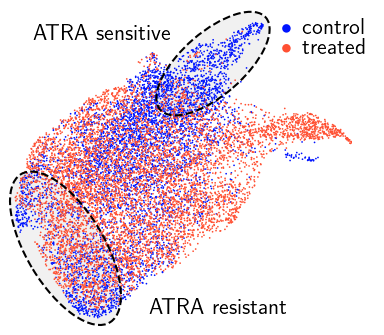

In [4]:
fig, ax = bt.omics.pl.embedding(
    adata,
    obs="condition",
    representation="X_umap",
    n_components=2,
    rotation=180,
    s=1.5,
    alpha=1,
    legend={
        "ncol": 1,
        "markerscale": 5,
        "frameon": False,
        "loc": "upper right",
        "bbox_to_anchor": (1.1, 1.05),
        "handletextpad": -0.3,
        "labelspacing": 0,
        "fontsize": 16,
    },
    figheight=4,
    figwidth=5.5,
    xlabel=r"$\mathrm{UMAP_{1}}$",
    ylabel=r"$\mathrm{UMAP_{2}}$",
)
plt.text(1, 16.8, "ATRA sensitive", fontsize=16, family="serif")
add_ellipse((15, 15.0), 10.8, 4.8, 40)
plt.text(10.0, -4.0, "ATRA resistant", fontsize=16, family="serif")
add_ellipse((3.5, 1.0), 13.2, 6.0, -58)
plt.axis(False)
plt.savefig(FIGURE_DIR / "umap_conditions.pdf")
plt.show()
plt.close()

**Integrated UMAP by annotation**<a class="anchor" id="fig-umap-label"></a>

The same embedding is coloured according to the manually assigned cell annotations used throughout the remainder of the analysis.

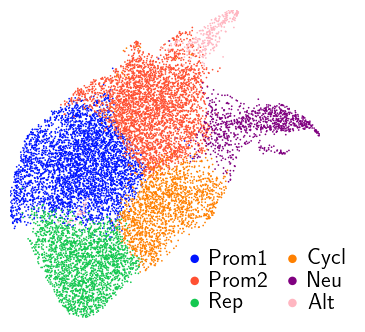

In [5]:
bt.omics.pl.embedding(
    adata,
    obs="label",
    representation="X_umap",
    n_components=2,
    rotation=180,
    s=1.5,
    alpha=1,
    legend={
        "ncol": 2,
        "markerscale": 5,
        "frameon": False,
        "edgecolor": bt.omics.pl.get_color("black"),
        "shadow": False,
        "loc": "lower right",
        "bbox_to_anchor": (1.15, -0.05),
        "columnspacing": 0,
        "handletextpad": -0.3,
        "labelspacing": 0.1,
        "fontsize": 16,
    },
    figheight=4,
    figwidth=5,
    xlabel=r"$\mathrm{UMAP_{1}}$",
    ylabel=r"$\mathrm{UMAP_{2}}$",
)
plt.axis(False)
plt.savefig(FIGURE_DIR / "umap_labels.pdf")
plt.show()
plt.close()

### Cell population composition <a class="anchor" id="table-cell-composition"></a>

Cell counts and within-condition percentages quantify the changes in population composition induced by ATRA treatment. In particular, `Cycl` expands from 7.7% to 18.0% of cells, whereas `Rep` remains comparatively stable (17.5% and 18.4%, respectively).

In [ ]:
composition_counts = (
    pd.crosstab(adata.obs["label"], adata.obs["condition"])
    .reindex(index=labels_order, columns=["control", "treated"], fill_value=0)
)
composition_proportions = composition_counts.div(
    composition_counts.sum(axis="index"),
    axis="columns",
)

composition_table = composition_counts.copy()
for condition in composition_table:
    composition_table[condition] = [
        f"{count:,} ({proportion:.1%})"
        for count, proportion in zip(
            composition_counts[condition],
            composition_proportions[condition],
        )
    ]

composition_table.loc["Total"] = [
    f"{count:,} (100.0%)" for count in composition_counts.sum(axis="index")
]
composition_table.index.name = "annotation"
composition_table.columns = ["control, n (%)", "ATRA-treated, n (%)"]
display(composition_table)

,"control, n (%)","ATRA-treated, n (%)"
annotation,,
Prom1,"1,534 (29.0%)","2,281 (33.3%)"
Prom2,"2,061 (39.0%)","1,221 (17.8%)"
Rep,923 (17.5%),"1,261 (18.4%)"
Cycl,408 (7.7%),"1,234 (18.0%)"
Neu,109 (2.1%),806 (11.8%)
Alt,250 (4.7%),52 (0.8%)
Total,"5,285 (100.0%)","6,855 (100.0%)"


### Neutrophil marker expression

Canonical neutrophil markers (`S100a8`, `S100a9`, `Ly6g`, `Ngp`) and the myeloid regulator `Spi1` are inspected directly using kernel density estimates. Unlike the manuscript figures, this diagnostic view provides a gene-level assessment of the annotation by showing the distribution of expression across cell populations.

When examining these plots, the Neu population is expected to exhibit a clear rightward shift relative to the remaining annotated populations, reflecting activation of the neutrophil transcriptional programme.

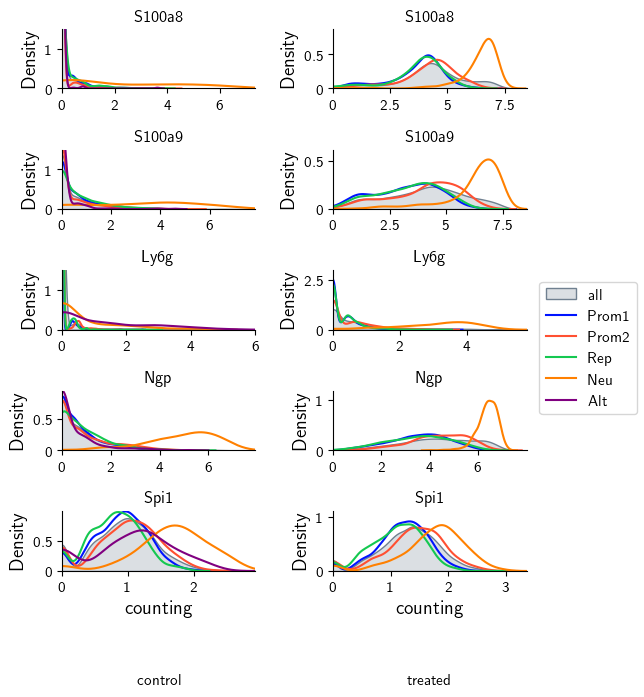

In [6]:
adata.obs["trunc_label"] = adata.obs["label"].mask(
    adata.obs["label"].eq("Cycl")
    | (adata.obs["condition"].eq("treated") & adata.obs["label"].eq("Alt"))
)

neutrophil_marker_genes = ["S100a8", "S100a9", "Ly6g", "Ngp", "Spi1"]
condition_adatas = {
    condition: adata[adata.obs["condition"].eq(condition)]
    for condition in ["control", "treated"]
}

fig, axes = plt.subplots(
    len(neutrophil_marker_genes),
    len(condition_adatas),
    figsize=(6.5, 1.4 * len(neutrophil_marker_genes)),
    sharex=False,
    sharey=False,
)

for row, gene in enumerate(neutrophil_marker_genes):
    for col, adata_condition in enumerate(condition_adatas.values()):
        ax = axes[row, col]
        bt.omics.pl.density(
            adata_condition,
            feature=gene,
            expression="log-norm",
            obs="trunc_label",
            show_global=True,
            clip_outliers=False,
            legend=False,
            title=gene,
            xlabel=None,
            ylabel=None,
            ax=ax,
        )
        ax.title.set_fontsize(12)
        counts = adata_condition[:, gene].layers["log-norm"]
        if hasattr(counts, "toarray"):
            counts = counts.toarray()
        counts = np.asarray(counts).squeeze()
        ax.set_xlim(counts.min(), counts.max() * 1.1)

for ax in axes[:-1, :].ravel():
    ax.set_xlabel("")

for ax in axes[:, 1]:
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.2)

for ax in axes.ravel():
    ax.tick_params(axis="both", labelsize=11)

for ax in axes[:3, 0]:
    ax.set_ylim(0, 1.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=11)
plt.tight_layout(rect=[0, 0.08, 0.85, 1])

for col, condition in enumerate(condition_adatas):
    pos = axes[0, col].get_position()
    fig.text(pos.x0 + pos.width / 2, 0.01, condition, ha="center", fontsize=11)

plt.show()
plt.close()

## Trajectory inference <a class="anchor" id="potency"></a>

Trajectory inference provides complementary evidence for defining dynamical constraints. Here, we focus on CytoTRACE potency scores as a measure of relative differentiation potential. The scores generated by scBOLT are stored with the cell annotations in the integrated AnnData object.

**Potency score interpretation**

The full CytoTRACE scale is displayed together with the associated potency classes. This exploratory view helps interpret the score ranges observed in the APL dataset.

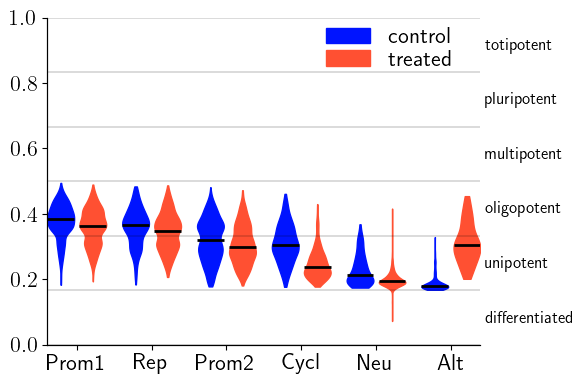

In [7]:
potency_ranges = np.linspace(0, 1, 7)
potency_labels = [
    "differentiated",
    "unipotent",
    "oligopotent",
    "multipotent",
    "pluripotent",
    "totipotent",
]

fig, ax, _ = bt.omics.pl.distribution(
    adata,
    obs="potency_score",
    groupby="label",
    hue="condition",
    kind="violin",
    sort="descending",
    median={
        "linestyle": "-",
        "linewidth": 2.0,
    },
    figwidth=6,
    figheight=4,
    legend={
        "bbox_to_anchor": (0.98, 1.03),
        "fontsize": 16,
        "columnspacing": 0.2,
        "labelspacing": 0.1,
        "frameon": False,
        "shadow": False,
    },
)
ax.set_ylim(0, 1)
ylim_min, ylim_max = 0, 1

potency_tick_positions = np.linspace(
    (ylim_max - ylim_min) / (2 * len(potency_labels)),
    1 - ((ylim_max - ylim_min) / (2 * len(potency_labels))),
    len(potency_labels),
)
twin_ax = ax.twinx()
twin_ax.set_yticks(potency_tick_positions)
twin_ax.set_yticklabels(potency_labels)
twin_ax.tick_params(axis="y", labelsize=12, length=0)

fig.tight_layout()
plt.hlines(
    y=potency_ranges,
    xmin=ax.get_xlim()[0],
    xmax=ax.get_xlim()[1],
    colors=bt.omics.pl.get_color("black"),
    linestyles="-",
    linewidth=0.2,
)
fig.tight_layout()
plt.show()
plt.close()

**Potency focus view** <a class="anchor" id="fig-potency"></a>

The manuscript panel focuses on the score range occupied by the APL cells.

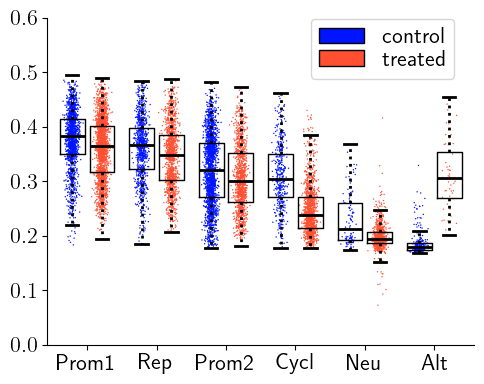

In [8]:
fig, ax, _ = bt.omics.pl.distribution(
    adata,
    obs="potency_score",
    groupby="label",
    hue="condition",
    sort="descending",
    points=True,
    figwidth=5,
    figheight=4,
    legend={
        "fontsize": 16,
        "columnspacing": 0.2,
        "labelspacing": 0.1,
    },
)

legend = ax.get_legend()
if legend is not None:
    legend.set_bbox_to_anchor((0.98, 1.03), transform=ax.transAxes)
    legend._loc = 1

ax.set_ylabel("Potency score", rotation=0, ha="left", va="bottom")
ax.yaxis.set_label_coords(0, 1.02)

ylim_min, ylim_max = 0, 0.6
plt.ylim((ylim_min, ylim_max))
fig.tight_layout()
plt.savefig(FIGURE_DIR / "potency_scores.pdf")
plt.show()
plt.close()

## Macrostate characterisation <a class="anchor" id="macrostates"></a>

Macrostates provide condition-specific representations of the transcriptomic landscape by grouping cells sharing similar phenotypic and transcriptional profiles. Here, we inspect the KNNSC macrostates identified by scBOLT.

**KNNSC macrostates** <a class="anchor" id="fig-macrostates"></a>

Macrostates are displayed independently for the control and ATRA-treated conditions to visualise the phenotype-specific cell populations identified by KNNSC.

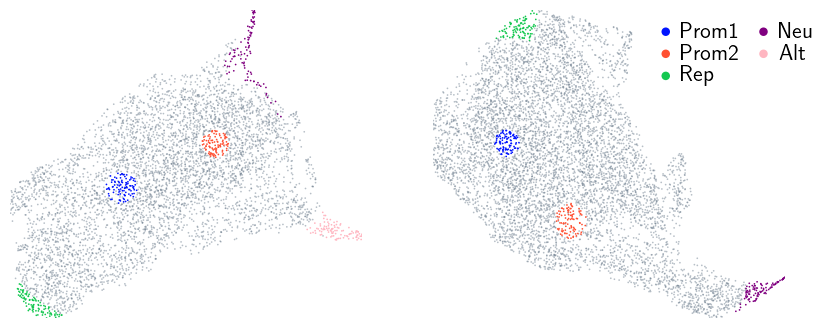

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

for ax, adata_condition, rotation in zip(
    axs,
    (adata_ctrl, adata_treated),
    (180, 180),
    strict=True,
):
    bt.omics.pl.embedding(
        adata_condition,
        obs="macrostate",
        representation="X_umap",
        n_components=2,
        s=1.5,
        alpha=(1, 0.5),
        legend=False,
        xlabel=r"$\mathrm{UMAP_{1}}$",
        ylabel=r"$\mathrm{UMAP_{2}}$",
        background_visible=False,
        rotation=rotation,
        ax=ax,
    )
    ax.grid(False)
    ax.axis(False)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    ncol=2,
    markerscale=5,
    frameon=False,
    edgecolor=bt.omics.pl.get_color("black"),
    shadow=False,
    columnspacing=0,
    handletextpad=-0.3,
    labelspacing=0.1,
    fontsize=16,
    loc="upper right",
    bbox_to_anchor=(0.95, 0.9),
)
plt.savefig(FIGURE_DIR / "umap_macrostates.pdf")
plt.show()
plt.close()

## Macrostate binarisation <a class="anchor" id="binarisation"></a>

Each macrostate is represented as a partially defined Boolean vector over genes, where `0`, `1`, and `*` respectively denote inactive, active, and undefined states. These vectors provide the Boolean abstraction used for subsequent constraint specification.

The complete binarisation matrix contains thousands of genes. Rather than displaying it in full, the notebook presents a compact preview illustrating the resulting Boolean state abstraction.

In [10]:
ax

<Axes: xlabel='$\\mathrm{UMAP_{1}}$', ylabel='$\\mathrm{UMAP_{2}}$'>

**Binarised macrostates**

The macrostate-level Boolean matrix generated by scBOLT is loaded and displayed as a compact gene preview.

In [10]:
bin_macrostates = (
    pd.read_csv(RESULTS_DIR / "spec" / "mstates.csv", index_col=0)
    .fillna("*")
    .replace("-", "_")
)
bin_macrostates.index = pd.MultiIndex.from_tuples(
    tuple("control" if value == "ctrl" else value for value in name.split("_"))
    for name in bin_macrostates.index
)

bin_macrostates_preview = bin_macrostates.iloc[:, :8]
display(bin_macrostates_preview)

0610009E02Rik 0610009L18Rik 0610030E20Rik 1110038B12Rik  \
control Alt               *             *           0.0             *   
        Neu               *           1.0           0.0             *   
        Prom1             *             *             *             *   
        Prom2           1.0             *             *             *   
        Rep               *             *             *           1.0   
treated Neu               *             *           0.0           0.0   
        Prom1             *             *           1.0             *   
        Prom2             *             *             *           0.0   
        Rep               *             *             *             *   

               1500009L16Rik 1500011B03Rik 1500015A07Rik 1600020E01Rik  
control Alt              0.0             *           0.0             *  
        Neu              0.0             *             *             *  
        Prom1            1.0             *             *             *  
        Prom2            1.0             *           1.0             *  
        Rep              1.0           1.0             *             *  
treated Neu              0.0           0.0           0.0           0.0  
        Prom1            0.0           0.0             *             *  
        Prom2            0.0           0.0             *             *  
        Rep              0.0             *             *             *

**GO-derived gene sets**

The Boolean abstraction preserves information about genes that are active, inactive, or left undefined within each macrostate. This enables the resulting Boolean profiles to be interpreted as compact representations of over- and under-expressed genes. Gene Ontology annotations are therefore mapped onto the binarised genes to compare functional programmes across macrostates. The GO basic ontology and NCBI gene-to-GO associations are downloaded on first use and cached in the operating system's temporary directory.

In [12]:
identifiers = bt.resources.ncbi.identifiers(
    organism="mouse",
    version="bundled",
)

go_background = list(bin_macrostates.columns)

go_basic_file, gene2go_file = get_go_resources()

print("Constructing go DAG...")
go_dag = GODag(str(go_basic_file))

gene2go = pd.concat(
    (
        chunk.loc[chunk["#tax_id"] == 10090]
        for chunk in pd.read_csv(
            gene2go_file,
            sep="\t",
            usecols=["#tax_id", "GeneID", "GO_ID"],
            chunksize=500_000,
        )
    ),
    ignore_index=True,
)

gene2go["gene"] = identifiers(
    list(gene2go["GeneID"].astype(str)),
    input_type="gene_id",
    output_type="symbol",
)

gene2go = gene2go.loc[gene2go["gene"].isin(go_background)]

go2gene = gene2go.groupby("GO_ID")["gene"].apply(lambda genes: set(genes)).to_dict()

Constructing go DAG...
/tmp/scbolt-case-studies/go/go_basic_2026-03-25.obo: fmt(1.2) rel(2026-03-25) 41,853 Terms


### Extended functional profiles <a class="anchor" id="fig-markers-extended"></a>

The extended panel summarises Boolean values across a broad collection of GO-derived gene sets. It provides an exploratory view of the functional programmes captured by the binarised macrostates.

gene_set,n_genes
respiratory burst/NADPH complex,4
neutrophil mechanisms,34
ER stress/ER unfolded protein,55
eosinophil mechanisms,4
activation/mye. leuc. diff.,22
inhibition/mye. leuc. diff.,15
neg. regulation/cell population,156
pos. regulation/cell population,202
pos. regulation/apoptosis,165
neg. regulation/apoptosis,202


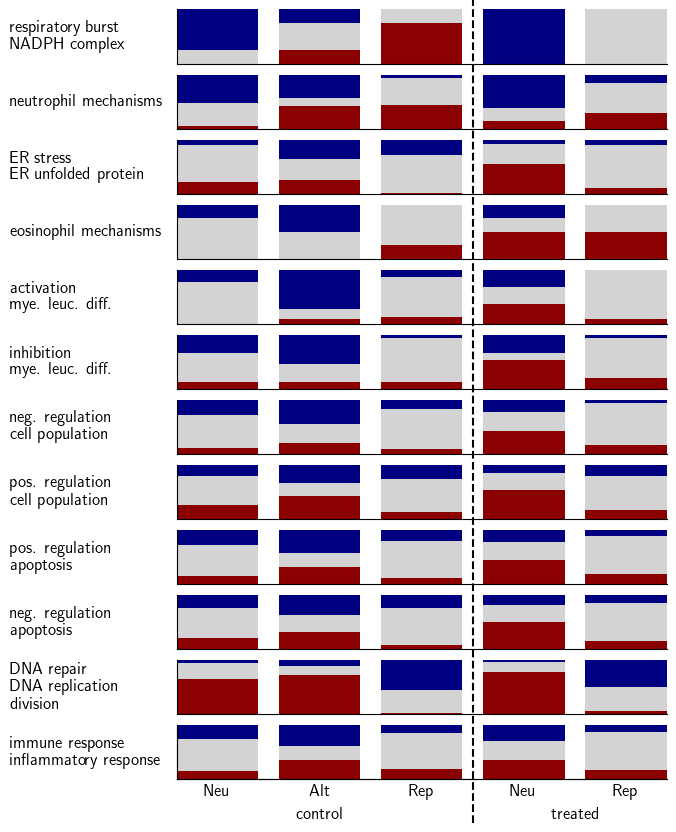

In [13]:
extended_go_terms = {
    "respiratory burst/NADPH complex": ["GO:0045730", "GO:0043020"],
    "neutrophil mechanisms": ["GO:0030593", "GO:0043315", "GO:0002446", "GO:0042119"],
    "ER stress/ER unfolded protein": ["GO:0034976", "GO:0030968"],
    "eosinophil mechanisms": ["GO:0030222", "GO:0048245", "GO:0043308"],
    "activation/mye. leuc. diff.": "GO:0002763",
    "inhibition/mye. leuc. diff.": "GO:0002762",
    "neg. regulation/cell population": "GO:0008285",
    "pos. regulation/cell population": "GO:0008284",
    "pos. regulation/apoptosis": "GO:0043065",
    "neg. regulation/apoptosis": "GO:0043066",
    "DNA repair/DNA replication/division": ["GO:0006281", "GO:0006260", "GO:0051301"],
    "immune response/inflammatory response": ["GO:0050778", "GO:0050729"],
}

extended_markers = {
    process_name: list(get_genes_from_go(go_ids, go2gene, go_dag))
    for process_name, go_ids in extended_go_terms.items()
}

extended_marker_summary = display_counts(
    {name: len(genes) for name, genes in extended_markers.items()},
    index_name="gene_set",
    count_name="n_genes",
)

bin_macrostates = bin_macrostates.rename(index={"ctrl": "control"}, level=0)

terminal_groups = [
    ("control", "Neu"),
    ("control", "Alt"),
    ("control", "Rep"),
    ("treated", "Neu"),
    ("treated", "Rep"),
]

plot_binarisation_grid(
    bin_macrostates,
    markers=extended_markers,
    groups=terminal_groups,
    figsize=(7, 10),
    label_fontsize=12,
    tick_label_fontsize=12,
    label_x=-0.34,
    left_margin=0.2,
)
plt.savefig(FIGURE_DIR / "markers_extended.pdf")
plt.show()
plt.close()

### Focused functional profiles <a class="anchor" id="fig-markers-paper"></a>

The focused panel restricts the comparison to the functional programmes highlighted in the manuscript: proliferation-associated processes, neutrophil mechanisms, and inflammatory or immune responses.

gene_set,n_genes
DNA repair/DNA replication/cell division,74
neutrophil/mechanisms,32
inflammatory/immune resp.,37


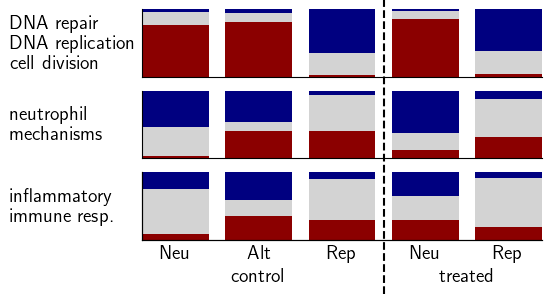

In [14]:
paper_go_terms = {
    "DNA repair/DNA replication/cell division": [
        "GO:0006281",
        "GO:0006260",
        "GO:0051301",
    ],
    "neutrophil/mechanisms": ["GO:0030593", "GO:0043315", "GO:0002446", "GO:0042119"],
    "inflammatory/immune resp.": ["GO:0050778", "GO:0050729"],
}

paper_markers = {
    process_name: list(get_genes_from_go(go_ids, go2gene, go_dag, depth=0))
    for process_name, go_ids in paper_go_terms.items()
}

paper_marker_summary = display_counts(
    {name: len(genes) for name, genes in paper_markers.items()},
    index_name="gene_set",
    count_name="n_genes",
)

plot_binarisation_grid(
    bin_macrostates,
    markers=paper_markers,
    groups=terminal_groups,
    figsize=(5, 3),
    label_fontsize=14,
    tick_label_fontsize=14,
    label_x=-0.33,
    left_margin=0.1,
)
plt.savefig(FIGURE_DIR / "markers.pdf", bbox_inches="tight")
plt.show()
plt.close()